In [3]:
import os
os.environ["JAX_PLATFORMS"] = "cpu"

import pickle
import numpy as np
import matplotlib.pyplot as plt

import jax
jax.config.update("jax_enable_x64", True)
import jaxsp as jsp



In [4]:
m22 = 10
R0 = 1
L_frac_out = 0.5

In [5]:
Check_dir   = "/rds/general/user/jd925/home/PhD_first_year/jaxsp/Adding_stellar_masses/Checkpoints/"


m22_str   = f"{m22:g}"
r0_str_in = f"{R0:g}"
lout_str  = f"{L_frac_out:g}"
Check_file_dir  = os.path.join(Check_dir, f"checkpoints_m22_{m22_str}_r0_{r0_str_in}_Lout_{lout_str}")


u = jsp.set_schroedinger_units(m22)
to_Kpc = float(u.to_Kpc)
to_kms = float(u.to_kms)
to_Gyr = float(u.to_Gyr)


# Load final checkpoint
ckpt_path = os.path.join(Check_file_dir, "checkpoint_final.pkl")
print(f"\nLoading {ckpt_path}")
with open(ckpt_path, "rb") as f:
    state = pickle.load(f)

n_steps = state["sim_time_step"]
n_ramp  = state.get("n_ramp_steps", 0)
dt_Gyr  = (state["sim_t"] / n_steps) * to_Gyr
print(f"Steps: {n_steps}, ramp steps: {n_ramp}, dt = {dt_Gyr:.5f} Gyr")

particles = state["particle_states"]

r_all  = np.array([p["r_values"] for p in particles])                              # (N_part, N_steps+1)
v_cart = np.array([[np.asarray(v) for v in p["velocities_cart"]] for p in particles])  # (N_part, N_steps+1, 3)
ke_all = np.array([p["kinetic_energy"]   for p in particles])                       # (N_part, N_steps+1)
pe_all = np.array([p["potential_energy"] for p in particles])                       # (N_part, N_steps+1)
am_all = np.array([p["ang_mom"]          for p in particles])                       # (N_part, N_steps+1[, 3])



Loading /rds/general/user/jd925/home/PhD_first_year/jaxsp/Adding_stellar_masses/Checkpoints/checkpoints_m22_10_r0_1_Lout_0.5/checkpoint_final.pkl
Steps: 1329, ramp steps: 0, dt = 0.00752 Gyr


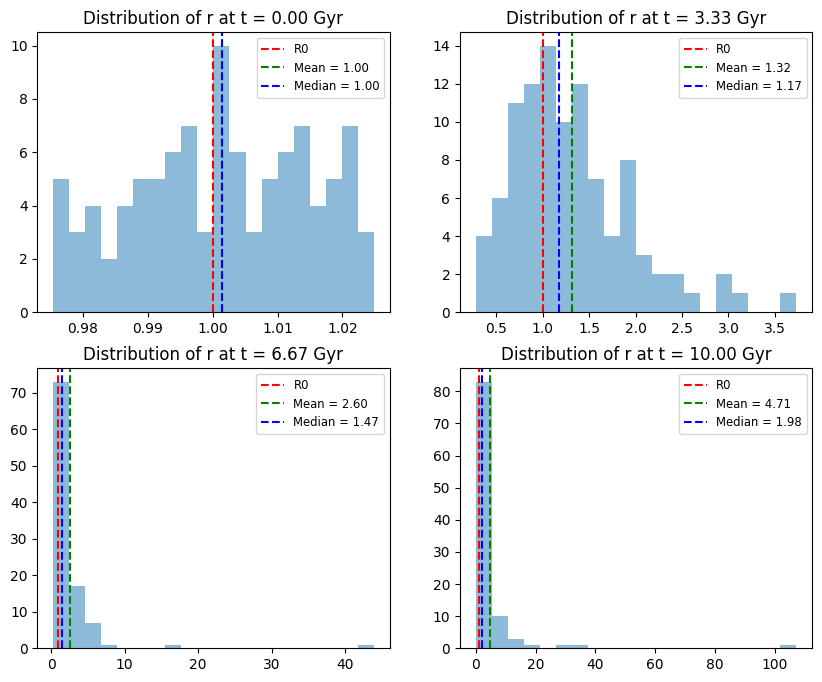

In [29]:

fig, ax = plt.subplots(2, 2, figsize=(10, 8))

start = 0
third = n_steps // 3
two_thirds = 2 * n_steps // 3
end = n_steps

mask = r_all * to_Kpc < 1000

ax[0, 0].hist(r_all[:, start][mask[:, start]] * to_Kpc, bins=20, alpha=0.5)
ax[0, 1].hist(r_all[:, third][mask[:, third]] * to_Kpc, bins=20, alpha=0.5)
ax[1, 0].hist(r_all[:, two_thirds][mask[:, two_thirds]] * to_Kpc, bins=20, alpha=0.5)
ax[1, 1].hist(r_all[:, end][mask[:, end]] * to_Kpc, bins=20, alpha=0.5)

ax[0, 0].axvline(1, color='r', linestyle='--', label='R0')
ax[1, 0].axvline(1, color='r', linestyle='--', label='R0')
ax[0, 1].axvline(1, color='r', linestyle='--', label='R0')
ax[1, 1].axvline(1, color='r', linestyle='--', label='R0')

ax[0, 0].axvline(np.mean(r_all[:, start][mask[:, start]] * to_Kpc), color='g', linestyle='--', label=f'Mean = {np.mean(r_all[:, start][mask[:, start]] * to_Kpc):.2f}')
ax[1, 0].axvline(np.mean(r_all[:, two_thirds][mask[:, two_thirds]] * to_Kpc), color='g', linestyle='--', label=f'Mean = {np.mean(r_all[:, two_thirds][mask[:, two_thirds]] * to_Kpc):.2f}')
ax[0, 1].axvline(np.mean(r_all[:, third][mask[:, third]] * to_Kpc), color='g', linestyle='--', label=f'Mean = {np.mean(r_all[:, third][mask[:, third]] * to_Kpc):.2f}')
ax[1, 1].axvline(np.mean(r_all[:, end][mask[:, end]] * to_Kpc), color='g', linestyle='--', label=f'Mean = {np.mean(r_all[:, end][mask[:, end]] * to_Kpc):.2f}')

ax[0, 0].axvline(np.median(r_all[:, start][mask[:, start]] * to_Kpc), color='b', linestyle='--', label=f'Median = {np.median(r_all[:, start][mask[:, start]] * to_Kpc):.2f}')
ax[1, 0].axvline(np.median(r_all[:, two_thirds][mask[:, two_thirds]] * to_Kpc), color='b', linestyle='--', label=f'Median = {np.median(r_all[:, two_thirds][mask[:, two_thirds]] * to_Kpc):.2f}')
ax[0, 1].axvline(np.median(r_all[:, third][mask[:, third]] * to_Kpc), color='b', linestyle='--', label=f'Median = {np.median(r_all[:, third][mask[:, third]] * to_Kpc):.2f}')
ax[1, 1].axvline(np.median(r_all[:, end][mask[:, end]] * to_Kpc), color='b', linestyle='--', label=f'Median = {np.median(r_all[:, end][mask[:, end]] * to_Kpc):.2f}')


ax[0, 0].set_title("Distribution of r at t = {:.2f} Gyr".format(start * dt_Gyr))
ax[0, 1].set_title("Distribution of r at t = {:.2f} Gyr".format(third * dt_Gyr))
ax[1, 0].set_title("Distribution of r at t = {:.2f} Gyr".format(two_thirds * dt_Gyr))
ax[1, 1].set_title("Distribution of r at t = {:.2f} Gyr".format(end * dt_Gyr))

ax[0,0].legend(fontsize='small')
ax[1,0].legend(fontsize='small')
ax[0,1].legend(fontsize='small')
ax[1,1].legend(fontsize='small')
